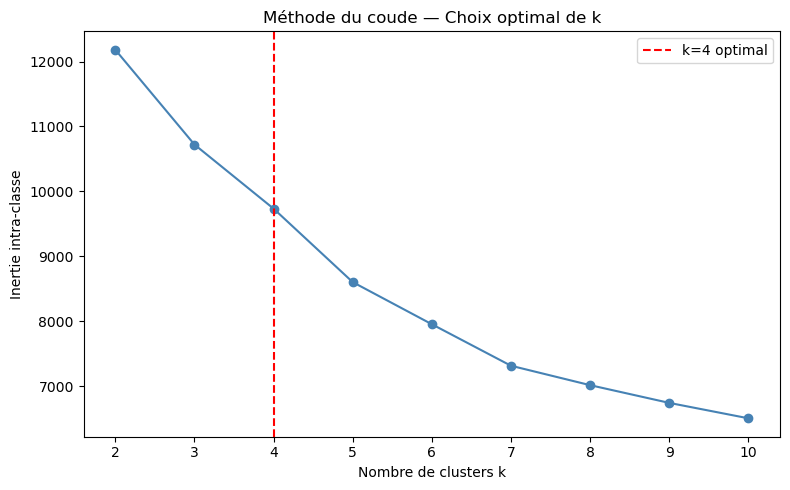

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

X_cr = pd.read_csv("X_cr.csv")
df   = pd.read_csv("df_prepared.csv")

# === PARTIE 1 : K-MEANS ===

# --- Méthode du coude (elbow method) pour choisir k ---
inerties = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cr)
    inerties.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inerties, 'o-', color='steelblue')
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie intra-classe")
plt.title("Méthode du coude — Choix optimal de k")
plt.axvline(x=4, color='red', linestyle='--', label='k=4 optimal')
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_elbow.png", dpi=150)
plt.show()




In [5]:
# --- Application de K-Means avec k=4 ---
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_cr)

print("=== K-Means — Répartition des clusters ===")
print(df['cluster_kmeans'].value_counts().sort_index())

# --- Caractérisation des clusters ---
print("\n=== Caractéristiques moyennes par cluster ===")
print(df.groupby('cluster_kmeans')[
    ['alcohol', 'volatile acidity', 'sulphates', 'pH', 'quality']
].mean().round(2))


=== K-Means — Répartition des clusters ===
cluster_kmeans
0    283
1    340
2    459
3    277
Name: count, dtype: int64

=== Caractéristiques moyennes par cluster ===
                alcohol  volatile acidity  sulphates    pH  quality
cluster_kmeans                                                     
0                  9.79              0.53       0.63  3.28     5.33
1                 10.57              0.41       0.77  3.17     5.91
2                  9.93              0.66       0.59  3.37     5.29
3                 11.75              0.46       0.68  3.42     6.13


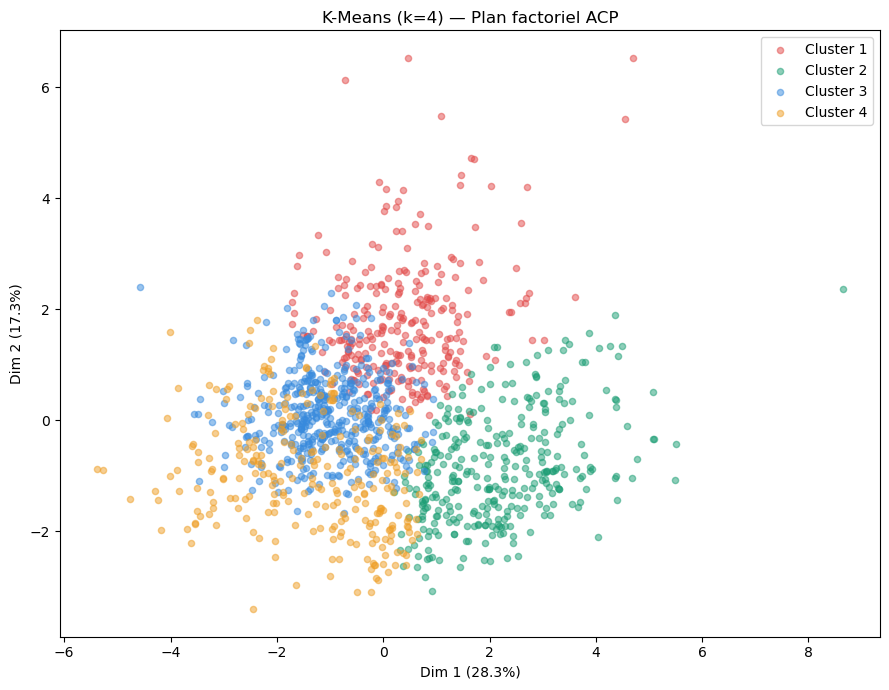

In [6]:
# --- Visualisation K-Means sur le plan ACP ---
from sklearn.decomposition import PCA
pca2 = PCA(n_components=2)
coord2 = pca2.fit_transform(X_cr)

plt.figure(figsize=(9, 7))
colors = ['#E24B4A', '#1D9E75', '#378ADD', '#EF9F27']
for c in range(k_optimal):
    mask = df['cluster_kmeans'] == c
    plt.scatter(coord2[mask, 0], coord2[mask, 1],
                color=colors[c], alpha=0.5, s=20, label=f'Cluster {c+1}')
plt.xlabel(f"Dim 1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("K-Means (k=4) — Plan factoriel ACP")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_plan_acp.png", dpi=150)
plt.show()



=== CLASSIFICATION HIÉRARCHIQUE ASCENDANTE ===


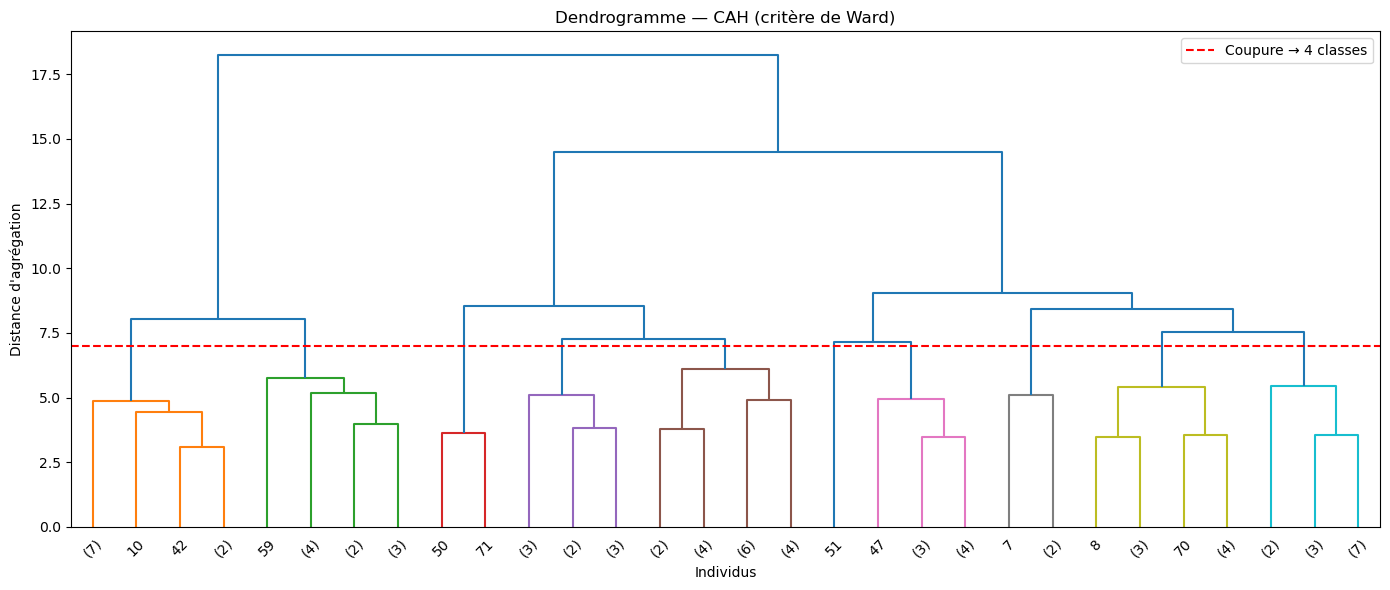

In [7]:
# === PARTIE 2 : CAH ===

print("\n\n=== CLASSIFICATION HIÉRARCHIQUE ASCENDANTE ===")

# Utiliser un sous-échantillon pour lisibilité du dendrogramme
sample = X_cr.sample(80, random_state=42)
Z = linkage(sample, method='ward', metric='euclidean')

# --- Dendrogramme ---
plt.figure(figsize=(14, 6))
dendrogram(Z, orientation='top', color_threshold=7,
           truncate_mode='lastp', p=30)
plt.axhline(y=7, color='red', linestyle='--', label='Coupure → 4 classes')
plt.title("Dendrogramme — CAH (critère de Ward)")
plt.xlabel("Individus")
plt.ylabel("Distance d'agrégation")
plt.legend()
plt.tight_layout()
plt.savefig("cah_dendrogramme.png", dpi=150)
plt.show()


In [8]:
# CAH sur toutes les données
Z_full = linkage(X_cr, method='ward', metric='euclidean')
df['cluster_cah'] = fcluster(Z_full, t=4, criterion='maxclust')

print("=== CAH — Répartition des classes ===")
print(df['cluster_cah'].value_counts().sort_index())

# Correspondance K-Means vs CAH
print("\n=== Correspondance K-Means / CAH ===")
print(pd.crosstab(df['cluster_kmeans'], df['cluster_cah'],
                  rownames=['K-Means'], colnames=['CAH']))

=== CAH — Répartition des classes ===
cluster_cah
1     31
2    230
3    466
4    632
Name: count, dtype: int64

=== Correspondance K-Means / CAH ===
CAH       1    2    3    4
K-Means                   
0         2    0  270   11
1        28  225   49   38
2         1    3   71  384
3         0    2   76  199
